# 2. Sampling with an exact score (Draft)
We use $p_0=\tfrac12N(-2,0.25)+\tfrac12N(2,0.25)$, $\beta=8$, and $\alpha_t=e^{-4t}$. Each component at time $t$ has mean $\alpha_t(\pm2)$ and variance $V_t=\alpha_t^2/4+1-\alpha_t^2$. Its exact score is the posterior-weighted mean of the component scores.

Compare explicit Euler for the probability-flow ODE and Euler–Maruyama for the reverse SDE. Outputs stop at $t_{\min}=0.01$ and are compared with **that** marginal. A normal terminal initialization only approximates $p_1$. No network is used.

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import logsumexp, ndtr
rng = np.random.default_rng(20260930)
started = time.perf_counter()
beta = 8.0
t_min = 0.01
means = np.array([-2., 2.])
V0 = 0.25

def alpha(t):
    return np.exp(-beta * np.asarray(t) / 2)

def parameters(t):
    a = alpha(t)
    return a * means, a*a*V0 + 1-a*a

def sample_data(n):
    return rng.choice(means, n) + np.sqrt(V0)*rng.normal(size=n)

def sample_marginal(n, t):
    a = alpha(t)
    return a*sample_data(n) + np.sqrt(1-a*a)*rng.normal(size=n)

def component_weights(x, t):
    m, V = parameters(t)
    logw = -(np.asarray(x)[..., None]-m)**2/(2*V)
    return np.exp(logw-logsumexp(logw, axis=-1, keepdims=True))

def density(x, t):
    m, V = parameters(t)
    return np.mean(np.exp(-(np.asarray(x)[...,None]-m)**2/(2*V))/np.sqrt(2*np.pi*V), axis=-1)

def cdf(x, t):
    m, V = parameters(t)
    return np.mean(ndtr((np.asarray(x)[...,None]-m)/np.sqrt(V)), axis=-1)

def score(x, t):
    m, V = parameters(t)
    return np.sum(component_weights(x,t)*(m-np.asarray(x)[...,None])/V, axis=-1)

def ecdf_error(x, t):
    x = np.sort(x)
    F = cdf(x,t)
    n = len(x)
    return max(np.max(np.arange(1,n+1)/n-F), np.max(F-np.arange(n)/n))

def sample_reverse(x1, steps=400, stochastic=False, score_fn=score, end=t_min, keep=8):
    x = np.asarray(x1).copy()
    times = np.linspace(1.,end,steps+1)
    traces = [x[:keep].copy()]
    for t, next_t in zip(times[:-1],times[1:]):
        h = t-next_t
        s = score_fn(x,t)
        # Increasing reverse clock: -f + g^2*s for SDE; half score for ODE.
        x += h*beta*(0.5*x+(1. if stochastic else 0.5)*s)
        if stochastic:
            x += np.sqrt(beta*h)*rng.normal(size=x.shape)
        traces.append(x[:keep].copy())
    return x, times, np.asarray(traces)


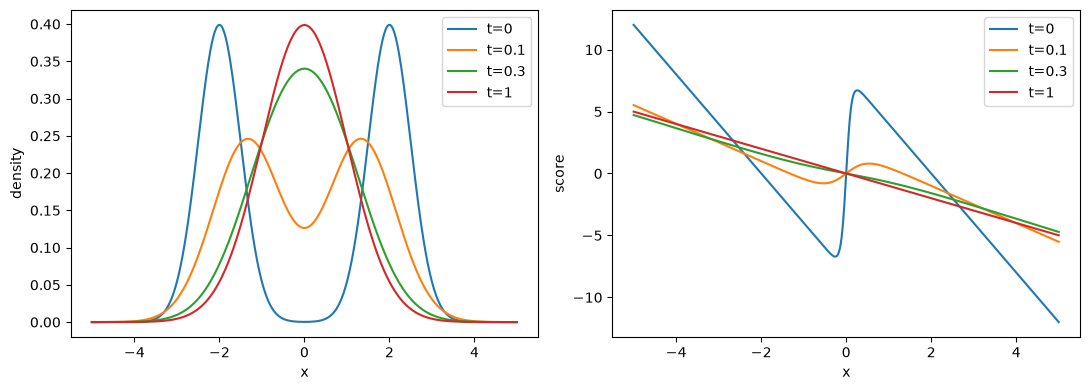

In [2]:
grid=np.linspace(-5,5,600)
fig,axes=plt.subplots(1,2,figsize=(11,4))
for t in [0.,.1,.3,1.]:
    axes[0].plot(grid,density(grid,t),label=f"t={t:g}")
    axes[1].plot(grid,score(grid,t),label=f"t={t:g}")
axes[0].set(xlabel="x",ylabel="density"); axes[1].set(xlabel="x",ylabel="score")
for ax in axes: ax.legend()
plt.tight_layout(); plt.show()
# Finite-difference check of the analytic score.
dx=1e-5
assert np.max(np.abs(score(grid,.2)-(np.log(density(grid+dx,.2))-np.log(density(grid-dx,.2)))/(2*dx)))<1e-7

ODE ECDF error vs p(t_min): 0.0053
reverse SDE ECDF error vs p(t_min): 0.0059


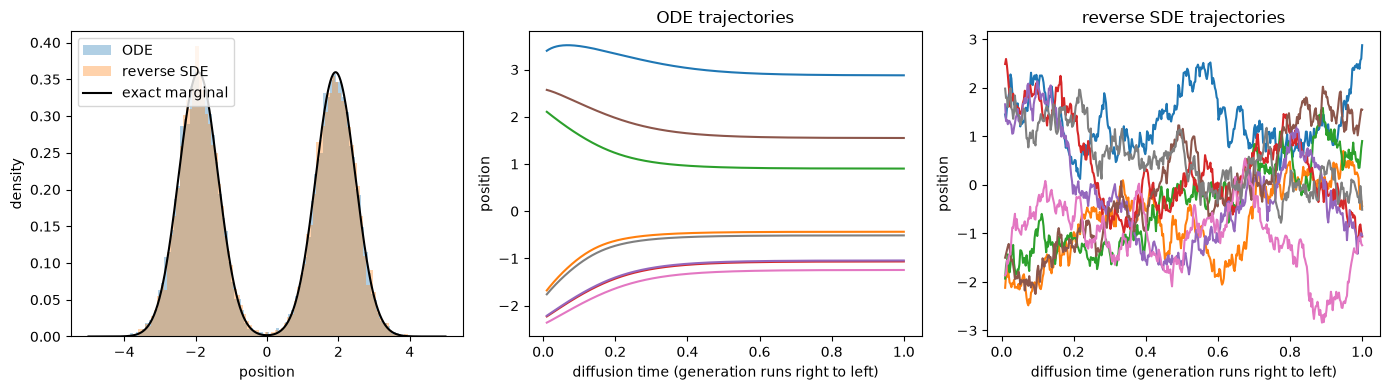

In [3]:
x1=sample_marginal(12000,1.)
ode,times,ode_paths=sample_reverse(x1)
sde,_,sde_paths=sample_reverse(x1,stochastic=True)
fig,axes=plt.subplots(1,3,figsize=(14,4))
for x,label in [(ode,"ODE"),(sde,"reverse SDE")]:
    axes[0].hist(x,bins=90,density=True,alpha=.35,label=label)
    print(label,"ECDF error vs p(t_min):",round(ecdf_error(x,t_min),4))
axes[0].plot(grid,density(grid,t_min),'k',label="exact marginal"); axes[0].legend()
axes[0].set(xlabel="position",ylabel="density")
for ax,paths,title in zip(axes[1:],[ode_paths,sde_paths],["ODE trajectories","reverse SDE trajectories"]):
    ax.plot(times,paths); ax.set(xlabel="diffusion time (generation runs right to left)",ylabel="position",title=title)
plt.tight_layout(); plt.show()

In [4]:
# Deterministic quantiles remove Monte Carlo noise from the ODE convergence check.
from scipy.optimize import brentq
u=(np.arange(1500)+.5)/1500
initial=np.array([brentq(lambda x: cdf(x,1.)-v,-10,10) for v in u])
reference=np.array([brentq(lambda x: cdf(x,t_min)-v,-10,10) for v in u])
errors=[]
for steps in [50,100,200,400]:
    out,_,_=sample_reverse(initial,steps=steps)
    err=np.mean(np.abs(out-reference)); errors.append(err)
    print(f"{steps=} mean quantile-position error={err:.6f}")
assert errors[-1]<errors[0]/4
# Same numerical solver, different terminal law. Matched quantiles isolate initialization.
from scipy.special import ndtri
normal_out,_,_=sample_reverse(ndtri(u),steps=400)
exact_out,_,_=sample_reverse(initial,steps=400)
print("Mean output difference caused by Gaussian prior:",np.mean(abs(normal_out-exact_out)))
# Gaussian-data check: p0=N(2,4), analytic deterministic transport.
m0,V_gauss=2.,4.
def gaussian_score(x,t):
    a=alpha(t); return -(x-a*m0)/(a*a*V_gauss+1-a*a)
z=rng.normal(size=4000)
a1,ae=alpha(1.),alpha(t_min)
x1g=a1*m0+np.sqrt(a1*a1*V_gauss+1-a1*a1)*z
exactg=ae*m0+np.sqrt(ae*ae*V_gauss+1-ae*ae)*z
numericg,_,_=sample_reverse(x1g,steps=800,score_fn=gaussian_score)
assert np.mean(abs(numericg-exactg))<0.02
print("Gaussian mean trajectory error:",np.mean(abs(numericg-exactg)))
print(f"Runtime: {time.perf_counter()-started:.1f} s")

steps=50 mean quantile-position error=0.073474
steps=100 mean quantile-position error=0.035981
steps=200 mean quantile-position error=0.017771
steps=400 mean quantile-position error=0.008827
Mean output difference caused by Gaussian prior: 0.0003598121425229904
Gaussian mean trajectory error: 0.0072098052677378914
Runtime: 1.4 s


**Exercises.** Lower beta to make terminal-prior error visible. Lower the stopping time and compare with clean data. Why do ODE and SDE paths differ despite similar endpoint histograms? A finite histogram cannot prove equality of their underlying laws.